# 📊 Notebook 03 — Matplotlib Visualizations

This notebook loads the aggregated datasets generated in Notebook 02 and creates all final plots for the PDF report.

## Plots to generate:
1. Yearly Sales Trend (Line Plot)
2. Region-wise Sales Comparison (Subplots)
3. Category-wise Sales (Bar Chart)
4. Sales Distribution (Histogram)
5. Discount vs Sales Scatter Plot (if discount exists)
6. 3-Month Moving Average Sales Trend

All visuals will be saved into the `visuals/` folder.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import os

# Create visuals folder if not exists
os.makedirs("visuals", exist_ok=True)

plt.style.use('ggplot')


In [3]:
# Load aggregated data created in Notebook 02
yearly = pd.read_csv(r"C:\Users\KUNAL\Downloads\AI ENGINEER\ProjectsX\global-superstore-analysis\data\yearly_sales.csv")
region = pd.read_csv(r"C:\Users\KUNAL\Downloads\AI ENGINEER\ProjectsX\global-superstore-analysis\data\region_sales.csv")
category = pd.read_csv(r"C:\Users\KUNAL\Downloads\AI ENGINEER\ProjectsX\global-superstore-analysis\data\category_sales.csv")
monthly = pd.read_csv(r"C:\Users\KUNAL\Downloads\AI ENGINEER\ProjectsX\global-superstore-analysis\data\monthly_sales.csv")

yearly.head(), region.head(), category.head(), monthly.head()


(   year    sales
 0  2011  2259511
 1  2012  2677493
 2  2013  3405860
 3  2014  4300041
 4  2015  2471205,
    region  year   sales
 0  Africa  2011  127186
 1  Africa  2012  144487
 2  Africa  2013  229069
 3  Africa  2014  283034
 4  Africa  2015  178000,
           category     sales
 0       Technology  12835878
 1        Furniture  12361392
 2  Office Supplies  12053433,
    month    sales
 0      1  2725471
 1      2  2516006
 2      3  2850127
 3      4  2660819
 4      5  2974253)

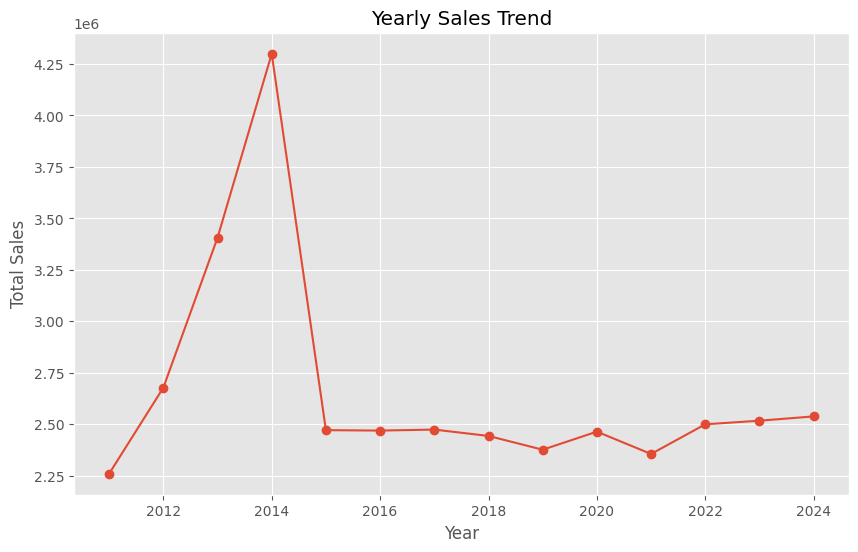

In [4]:
# YEARLY SALES TREND

plt.figure(figsize=(10,6))
plt.plot(yearly['year'], yearly['sales'], marker='o')
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)

plt.savefig("visuals/yearly_sales_trend.png", dpi=300)
plt.show()

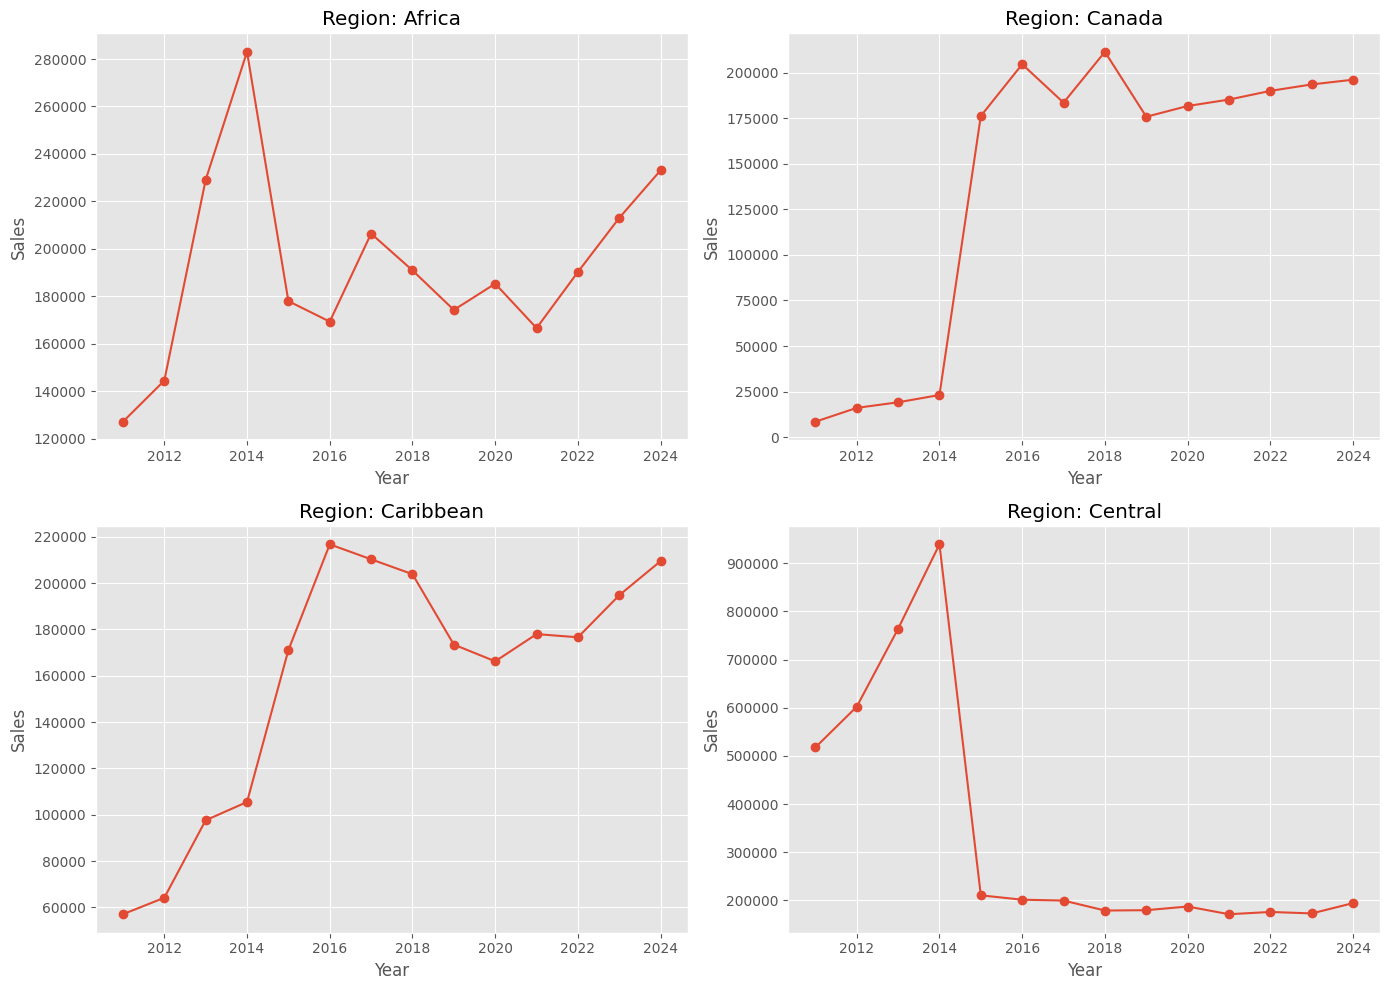

In [5]:
# REGION-WISE SALES (SUBPLOTS)

regions = region['region'].unique()
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14,10))

for ax, region_name in zip(axes.flatten(), regions):
    rdata = region[region['region'] == region_name]
    ax.plot(rdata['year'], rdata['sales'], marker='o')
    ax.set_title(f"Region: {region_name}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Sales")
    ax.grid(True)

plt.tight_layout()
plt.savefig("visuals/region_sales_subplots.png", dpi=300)
plt.show()


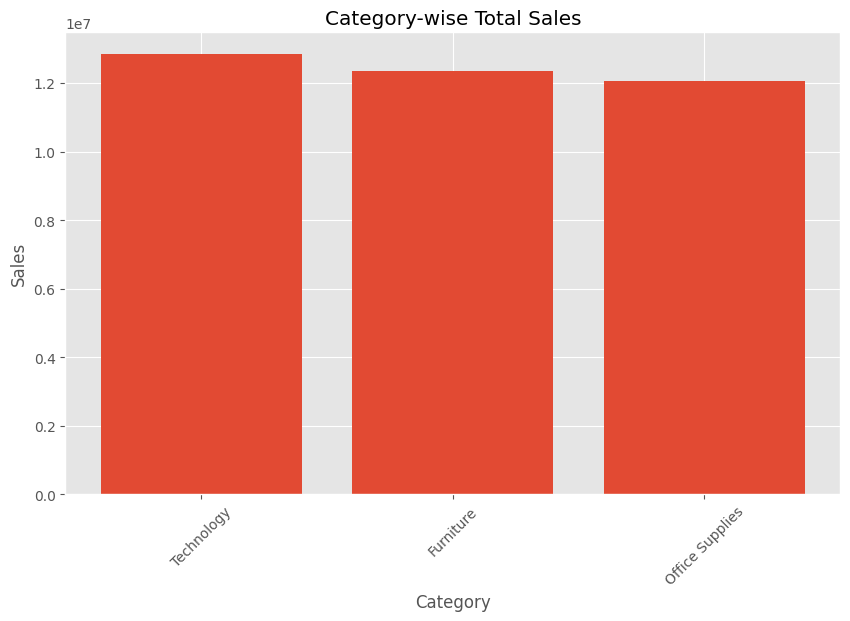

In [6]:
# CATEGORY SALES BAR CHART

plt.figure(figsize=(10,6))
plt.bar(category['category'], category['sales'])
plt.title("Category-wise Total Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True, axis='y')

plt.savefig("visuals/category_sales_bar.png", dpi=300)
plt.show()


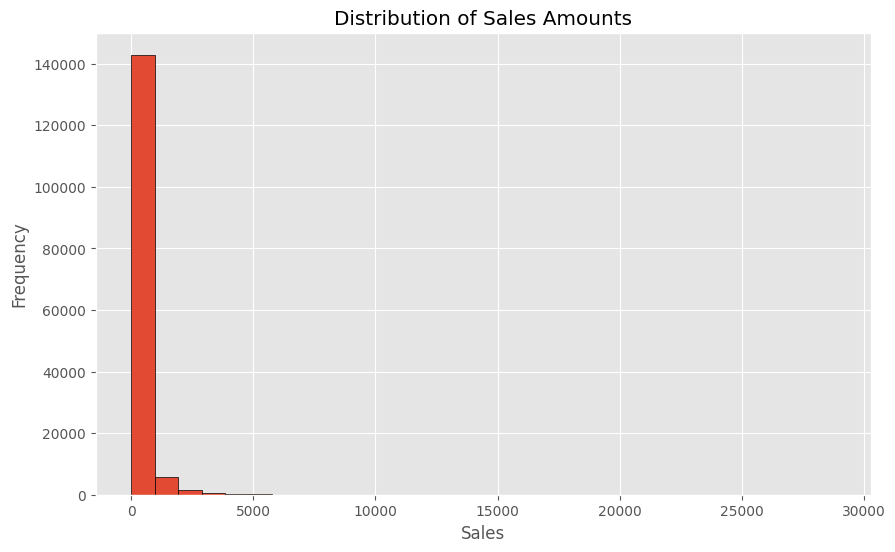

In [7]:
# SALES DISTRIBUTION HISTOGRAM
path = r"C:\Users\KUNAL\Downloads\AI ENGINEER\ProjectsX\global-superstore-analysis\data\superstore_cleaned.csv"
df = pd.read_csv(path, parse_dates=['order_date'])

plt.figure(figsize=(10,6))
plt.hist(df['sales'], bins=30, edgecolor='black')
plt.title("Distribution of Sales Amounts")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(True)

plt.savefig("visuals/sales_histogram.png", dpi=300)
plt.show()


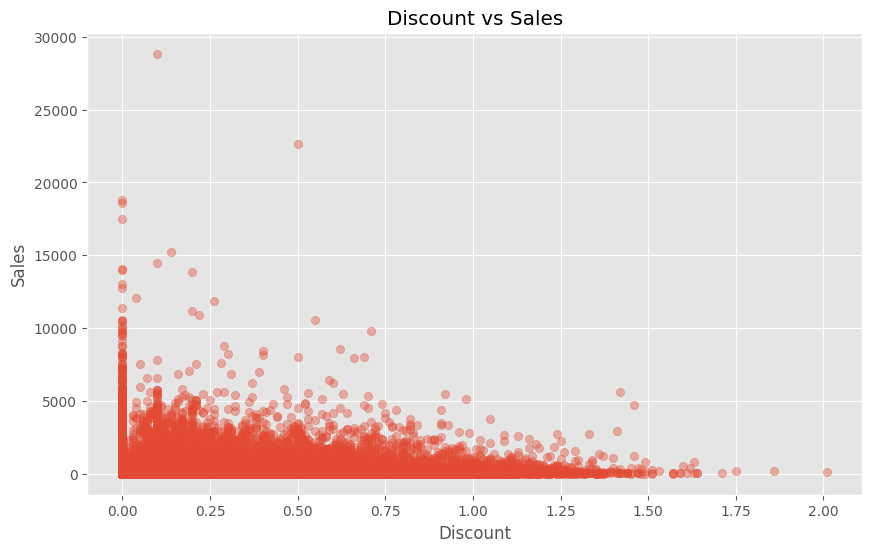

In [8]:
# DISCOUNT vs SALES SCATTER

plt.figure(figsize=(10,6))
plt.scatter(df['discount'], df['sales'], alpha=0.4)
plt.title("Discount vs Sales")
plt.xlabel("Discount")
plt.ylabel("Sales")
plt.grid(True)

plt.savefig("visuals/discount_vs_sales_scatter.png", dpi=300)
plt.show()


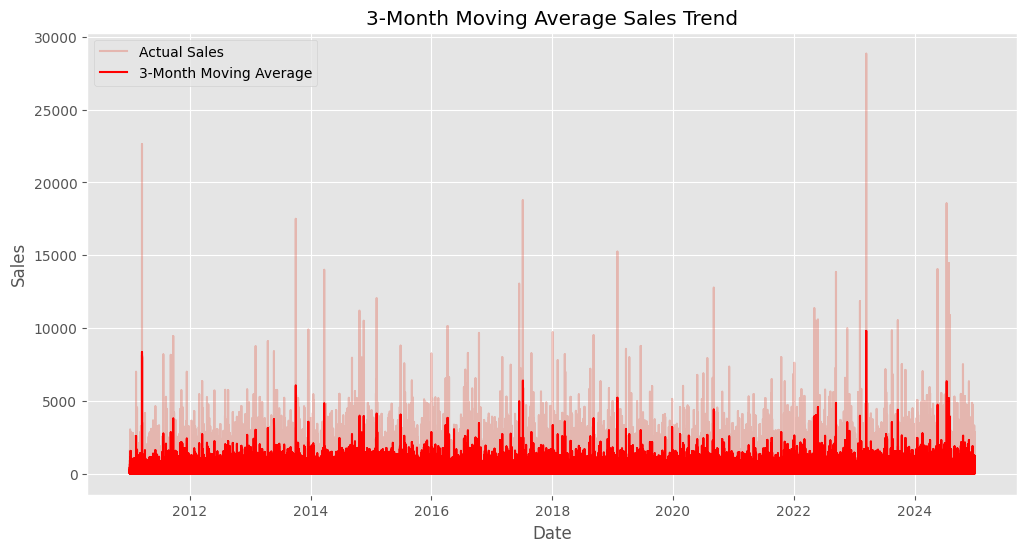

In [9]:
# MOVING AVERAGE TREND

df = df.sort_values("order_date")
df['MA_3'] = df['sales'].rolling(3).mean()

plt.figure(figsize=(12,6))
plt.plot(df['order_date'], df['sales'], alpha=0.3, label='Actual Sales')
plt.plot(df['order_date'], df['MA_3'], color='red', label='3-Month Moving Average')
plt.title("3-Month Moving Average Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.savefig("visuals/moving_average_trend.png", dpi=300)
plt.show()


# ✅ All Matplotlib Plots Generated Successfully

Visuals saved in `visuals/`:
- yearly_sales_trend.png
- region_sales_subplots.png
- category_sales_bar.png
- sales_histogram.png
- discount_vs_sales_scatter.png
- moving_average_trend.png

These are ready to be used in:

👉 Notebook 04 (PDF Report)

👉 GitHub README

👉 Portfolio
